In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from tqdm import tqdm

In [2]:
def add_intercept(x):
    """
      Dùng cho tất cả các bài trong file

    Args:
        x: 2D NumPy array.

    Returns:
        New matrix same as x with 1's in the 0th column.
    """
    new_x = np.zeros((x.shape[0], x.shape[1] + 1), dtype=x.dtype)
    new_x[:, 0] = 1
    new_x[:, 1:] = x

    return new_x


def load_dataset(csv_path, label_col='y', bias=False):
    """
    Dùng cho dataset ds1_train
    """


    # Validate label_col argument
    allowed_label_cols = ('y', 't')
    if label_col not in allowed_label_cols:
        raise ValueError('Invalid label_col: {} (expected {})'
                         .format(label_col, allowed_label_cols))

    # Load headers
    with open(csv_path, 'r') as csv_fh:
        headers = csv_fh.readline().strip().split(',')

    # Load features and labels
    x_cols = [i for i in range(len(headers)) if headers[i].startswith('x')]
    l_cols = [i for i in range(len(headers)) if headers[i] == label_col]
    inputs = np.loadtxt(csv_path, delimiter=',', skiprows=1, usecols=x_cols)
    labels = np.loadtxt(csv_path, delimiter=',', skiprows=1, usecols=l_cols)

    if inputs.ndim == 1:
        inputs = np.expand_dims(inputs, -1)

    if bias:
        inputs = add_intercept(inputs)

    return inputs, labels

Trong các buổi trước, ta đã tìm hiểu Logistic Regression và Softmax Regression. Trong bài thực hành này, ta sẽ tiếp tục mở rộng sang một khái niệm mới là "Mạng Nơ-ron" (Neural Network).



# I. Two Layer Network

Chúng ta định nghĩa một hàm được tham số hóa $h_\theta(x)$ với đầu vào $x$, tham số $\theta$, và đầu ra $y$, tức là ánh xạ $h_\theta : x \rightarrow y$. Một dạng tham số hóa đơn giản có thể là:

$$
h_\theta(x) = \max(wx + b, 0), \quad \text{với } \theta = (w, b) \in \mathbb{R}^2
$$

Ở đây, $h_\theta(x)$ trả về một giá trị duy nhất: hoặc $(wx + b)$, hoặc 0, tùy theo giá trị nào lớn hơn. Trong bối cảnh mạng nơ-ron, hàm $\max\{t, 0\}$ được gọi là ReLU, và thường ký hiệu là $\text{ReLU}(t) \triangleq \max\{t, 0\}$.

Một hàm phi tuyến một chiều ánh xạ từ $\mathbb{R}$ sang $\mathbb{R}$, chẳng hạn như ReLU, được gọi là **hàm kích hoạt** (activation function). Mô hình $h_\theta(x)$ được xem là có một nơ-ron vì nó chỉ sử dụng một hàm kích hoạt phi tuyến duy nhất.

Khi đầu vào $x \in \mathbb{R}^d$ là véc-tơ nhiều chiều, một mạng nơ-ron với đúng một nơ-ron có thể được viết dưới dạng:

$$
h_\theta(x) = \text{ReLU}(w^T x + b),
\quad \text{với } w \in \mathbb{R}^d,\ b \in \mathbb{R},\ \theta = (w, b)
$$

Trong đó, $b$ được gọi là **bias**, còn $w$ được gọi là **véc-tơ trọng số** (weight vector). Một mạng nơ-ron như vậy được xem là có một tầng (layer).

**Lưu ý**: Để thuận tiện cho trình bày, các công thức dẫn dắt đều sử dụng ReLU, tuy nhiên, các bạn có thể dễ dàng thay thế Hàm kích hoạt này bằng các hàm khác như Tanh, Sigmoid, vân vân mà không làm thay đổi công thức.

In [3]:
def ReLU(x):
    return np.maximum(0, x)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def tanh(x):
    return (np.exp(x) - np.exp(-x)) / (np.exp(x) + np.exp(-x))

def softmax(x):
    e_x = np.exp(x - np.max(x))
    return e_x / e_x.sum(axis=0)

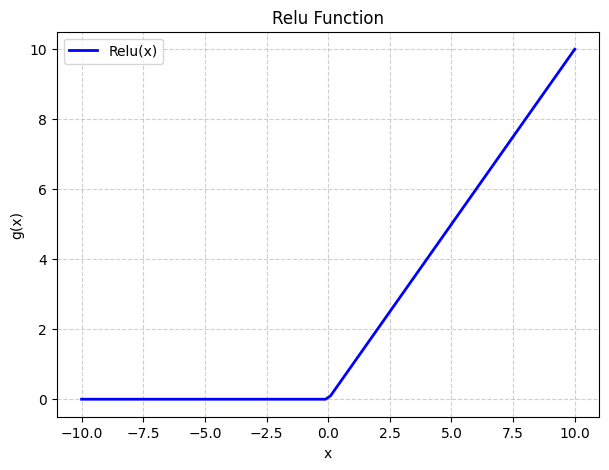

In [4]:
x = np.linspace(-10, 10, 100)
y = ReLU(x)

plt.figure(figsize=(7, 5))
plt.plot(x, y, color='blue', linewidth=2, label='Relu(x)')
plt.title("Relu Function")
plt.xlabel("x")
plt.ylabel("g(x)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.show()

## Định nghĩa tổng quát

Để mô tả một mạng hai tầng fully-connected một cách tổng quát, giả sử mạng có:

- $d$ đặc trưng đầu vào  
- $m$ nơ-ron ẩn (hidden units)  

Với đầu vào $x \in \mathbb{R}^d$, ta định nghĩa tầng ẩn như sau:

$$
\forall j \in \{1, \ldots, m\}, \quad z_j = w_j^{[1]T} x + b_j^{[1]}, \quad w_j^{[1]} \in \mathbb{R}^d,\ b_j^{[1]} \in \mathbb{R}
$$

$$
a_j = \text{ReLU}(z_j)
$$

Gom tất cả các giá trị $a_j$ thành một vector:

$$
a = [a_1, \ldots, a_m]^T \in \mathbb{R}^m
$$

Tầng output được biểu diễn dưới dạng tuyến tính:

$$
h_\theta(x) = w^{[2]T} a + b^{[2]}, \quad w^{[2]} \in \mathbb{R}^m,\ b^{[2]} \in \mathbb{R}
$$

Chúng ta xét việc vector hóa mạng nơ-ron fully-connected hai tầng. Trước tiên, ta ghép tất cả các vector trọng số $w_j^{[1]}$ lại thành một ma trận trọng số $W^{[1]} \in \mathbb{R}^{m \times d}$ như sau:

$$
W^{[1]} =
\begin{bmatrix}
-\, w_1^{[1]T} \,- \\
-\, w_2^{[1]T} \,- \\
\vdots \\
-\, w_m^{[1]T} \,-
\end{bmatrix}
\in \mathbb{R}^{m \times d}
$$

Theo định nghĩa của phép nhân ma trận–vector, ta có thể viết $z = [z_1, \ldots, z_m]^T \in \mathbb{R}^m$ dưới dạng:
$$
\underbrace{
\begin{bmatrix}
z_1 \\
\vdots \\
z_m
\end{bmatrix}
}_{\mathbf{z} \in \mathbb{R}^{m \times 1}}
=
\underbrace{
\begin{bmatrix}
-\, w_1^{[1]T} \,- \\
-\, w_2^{[1]T} \,- \\
\vdots \\
-\, w_m^{[1]T} \,-
\end{bmatrix}
}_{\mathbf{W}^{[1]} \in \mathbb{R}^{m \times d}}
\underbrace{
\begin{bmatrix}
x_1 \\
x_2 \\
\vdots \\
x_d
\end{bmatrix}
}_{\mathbf{x} \in \mathbb{R}^{d \times 1}}
+
\underbrace{
\begin{bmatrix}
b_1^{[1]} \\
b_2^{[1]} \\
\vdots \\
b_m^{[1]}
\end{bmatrix}
}_{\mathbf{b}^{[1]} \in \mathbb{R}^{m \times 1}}
$$

Tức là có thể viết gọn:

$$
z = W^{[1]}x + b^{[1]}
$$

Việc tính toán các **kích hoạt** $\mathbf{a} \in \mathbb{R}^m$ từ $\mathbf{z} \in \mathbb{R}^m$ liên quan đến việc áp dụng **từng phần tử** hàm **phi tuyến ReLU**, có thể được tính toán song song một cách hiệu quả. Áp dụng mở rộng hàm ReLU cho việc áp dụng từng phần tử (nghĩa là, đối với một vector $\mathbf{t} \in \mathbb{R}^d$, $\text{ReLU}(\mathbf{t})$ là một vector sao cho $\text{ReLU}(\mathbf{t})_i = \text{ReLU}(t_i)$), ta có:

$$
\mathbf{a} = \text{ReLU}(\mathbf{z})
$$

---

Định nghĩa $\mathbf{W}^{[2]} = [\mathbf{w}_1^{[2]T}] \in \mathbb{R}^{1 \times m}$ một cách tương tự. Sau đó, mô hình có thể được tóm tắt là:

$$
\mathbf{a} = \text{ReLU}(\mathbf{W}^{[1]}\mathbf{x} + \mathbf{b}^{[1]})
$$

$$
h_\theta(\mathbf{x}) = \mathbf{W}^{[2]}\mathbf{a} + \mathbf{b}^{[2]}
$$

---

Ở đây **$\theta$** bao gồm $\mathbf{W}^{[1]}$, $\mathbf{W}^{[2]}$ (thường được gọi là các **ma trận trọng số**) và $\mathbf{b}^{[1]}$, $\mathbf{b}^{[2]}$ (được gọi là các **độ lệch** - *bias*). Tập hợp $\mathbf{W}^{[1]}, \mathbf{b}^{[1]}$ được gọi là **tầng thứ nhất**, và $\mathbf{W}^{[2]}, \mathbf{b}^{[2]}$ là **tầng thứ hai**. Kích hoạt $\mathbf{a}$ được gọi là **tầng ẩn** (*hidden layer*). Một mạng nơ-ron hai tầng cũng được gọi là **mạng nơ-ron một tầng ẩn**.



In [5]:
np.random.seed(0)
m, d = 3, 4  # hidden units, input dimension

x = np.array([0.5, 0.2, -0.1, 0.8]).reshape(d, 1)  # (d,1) column vector
y = np.array([[1.25]])

W1 = np.random.randn(m, d) * 0.01  # (m,d)
b1 = np.random.randn(m, 1) * 0.01  # (m,1)
w2 = np.random.randn(m, 1) * 0.01  # (m,1)
b2 = np.random.randn(1, 1) * 0.01  # (1,1)

z_loop = np.zeros((m, 1))
a_loop = np.zeros((m, 1))

### ----- YOUR CODE START HERE ----- ###

# TODO 1: Tính z_j cho từng neuron ẩn (duyệt j từ 0 đến m-1)
# TODO 2: Lưu giá trị z_j và tính a_j = ReLU(z_j)
for j in range(m):
    z_j = np.dot(W1[j, :], x) + b1[j, 0]
    a_j = ReLU(z_j)

    z_loop[j, 0] = z_j
    a_loop[j, 0] = a_j

# TODO 3: Tính đầu ra o_loop của mạng (dạng (1,1))
o_loop = np.dot(w2.T, a_loop) + b2

### ----- YOUR CODE END HERE ----- ###

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_11080\3315958475.py:23: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  z_loop[j, 0] = z_j
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_11080\3315958475.py:24: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  a_loop[j, 0] = a_j


## Lan Truyền Ngược cho Mạng Nơ-ron Hai Lớp

Sử dụng ký hiệu:
* $x$: Vector đầu vào (Input vector)
* $y$: Giá trị mục tiêu (Target value)
* $o$: Đầu ra cuối cùng $h_{\theta}(x)$ (Final output)
* $w^{[1]}$: Trọng số lớp ẩn (Vector)
* $b^{[1]}$: Độ lệch lớp ẩn (Scalar)
* $w^{[2]}$: Trọng số lớp đầu ra (Vector)
* $b^{[2]}$: Độ lệch lớp đầu ra (Scalar)

---

### 1. Lan Truyền Thuận (Forward Propagation) - Định nghĩa Mạng

| Tính toán (Calculation) | Công thức (Equation) |
| :--- | :--- |
| **Đầu vào tuyến tính (Lớp Ẩn $j$):** | $z_j = w_j^{[1]\top} x + b_j^{[1]}$ |
| **Đầu ra lớp ẩn:** | $a_j = \text{ReLU}(z_j)$, $a = [a_1, \dots, a_m]^\top$ |
| **Đầu ra cuối cùng (Output $o$):** | $o = w^{[2]\top} a + b^{[2]}$ |
| **Hàm mất mát (Loss $J$):** | $J = \frac{1}{2}(y - o)^2$ |

---

### 2. Lan Truyền Ngược (Backward Propagation) - Tính Gradient

#### a. Gradient Lớp Đầu ra ($w^{[2]}$)

Gradient đối với tọa độ thứ $\ell$ của trọng số lớp đầu ra $w^{[2]}$:

$$\frac{\partial J}{\partial (w_{\ell}^{[2]})} = \frac{\partial J}{\partial o} \cdot \frac{\partial o}{\partial (w_{\ell}^{[2]})} $$
$$\frac{\partial J}{\partial (w_{\ell}^{[2]})} = (o - y) \cdot a_{\ell}$$

* **Đạo hàm cục bộ:** $\frac{\partial J}{\partial o} = (o - y)$ và $\frac{\partial o}{\partial (w_{\ell}^{[2]})} = a_{\ell}$.

#### b. Gradient Lớp Ẩn ($w_{j}^{[1]}$)

Gradient đối với tọa độ thứ $\ell$ của trọng số $w_j^{[1]}$ của nơ-ron ẩn $j$:

$$\frac{\partial J}{\partial (w_{j}^{[1]})_{\ell}} = \frac{\partial J}{\partial z_j} \cdot \frac{\partial z_j}{\partial (w_{j}^{[1]})_{\ell}}$$

**i. Tính $\frac{\partial J}{\partial a_j}$ và $\frac{\partial J}{\partial z_j}$ (Backprop qua Lớp Output):**
$$\frac{\partial J}{\partial a_j} = \frac{\partial J}{\partial o} \cdot \frac{\partial o}{\partial a_j} = (o - y) \cdot (w^{[2]})_j$$

$$\frac{\partial J}{\partial z_j} = \frac{\partial J}{\partial a_j} \cdot \frac{\partial a_j}{\partial z_j} $$
$$\frac{\partial J}{\partial z_j} = (o - y) \cdot (w^{[2]})_j \cdot \text{ReLU}'(z_j)$$

**ii. Kết hợp cuối cùng:**
Vì $\frac{\partial z_j}{\partial (w_{j}^{[1]})_{\ell}} = x_{\ell}$, ta có:
$$\frac{\partial J}{\partial (w_{j}^{[1]})_{\ell}} = (o - y) \cdot (w^{[2]})_j \cdot \text{ReLU}'(z_j) \cdot x_{\ell}$$

In [6]:
### ----- YOUR CODE START HERE ----- ###
# TODO 1: Tính Loss
J_loop = 0.5 * (o_loop - y) ** 2  # (1,1)

# TODO 2: Tính đạo hàm của loss theo o: dJ/do
dJ_do = o_loop - y  # (1,1)

# TODO 3: Gradients cho lớp output: dJ/dw2 (m,1) và dJ/db2 (1,1)
dJ_dw2_loop = np.zeros_like(w2)  # (m,1)
for j in range(m):
    # TODO 3.1: dJ/dw2_j = dJ/do * a_j
    dJ_dw2_loop[j, 0] = dJ_do * a_loop[j, 0]  # scalar

# TODO 3.2: grad bias output
dJ_db2_loop = dJ_do  # (1,1)

# TODO 4: Backprop về hidden: tính dJ/dz_j, rồi dJ/dW1 và dJ/db1
dJ_dW1_loop = np.zeros_like(W1)  # (m,d)
dJ_db1_loop = np.zeros_like(b1)  # (m,1)

for j in range(m):
    # TODO 4.1: dJ/da_j = dJ/do * w2_j
    dJ_da_j = dJ_do * w2[j, 0]  # scalar

    # TODO 4.2: đạo hàm của ReLU: dReLU/dz = 1 nếu z_j > 0, else 0
    relu_prime = 1 if z_loop[j, 0] > 0 else 0

    # TODO 4.3: dJ/dz_j = dJ/da_j * dReLU/dz
    dJ_dz_j = dJ_da_j * relu_prime  # scalar

    # TODO 4.4: dJ/dW1[j, l] = dJ/dz_j * x_l  (duyệt l từ 0..d-1)
    for l in range(d):
        dJ_dW1_loop[j, l] = dJ_dz_j * x[l, 0]  # scalar

    # TODO 4.5: dJ/db1[j] = dJ/dz_j
    dJ_db1_loop[j, 0] = dJ_dz_j  # scalar

### ----- YOUR CODE END HERE ----- ###

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_11080\101815038.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  dJ_dw2_loop[j, 0] = dJ_do * a_loop[j, 0]  # scalar
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_11080\101815038.py:33: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  dJ_dW1_loop[j, l] = dJ_dz_j * x[l, 0]  # scalar
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_11080\101815038.py:36: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  dJ_db1_loop[j, 0] = dJ_dz_j  # 

### Lan Truyền Ngược Dạng Vector hóa

1. **Tính Lỗi Lớp Đầu ra $\delta^{[2]}$:**
   $$\delta^{[2]} = o - y \in \mathbb{R}$$

2. **Tính Lỗi Lớp Ẩn $\delta^{[1]}$:**
   $$\delta^{[1]} = \delta^{[2]} \cdot w^{[2]} \odot \text{ReLU}'(z) \in \mathbb{R}^m$$
   *(Lưu ý: Nhân vô hướng $\delta^{[2]}$ với vector $w^{[2]}$ sau đó thực hiện phép nhân từng phần tử $\odot$)*.

3. **Tính Gradient Cuối cùng:**
   $$\frac{\partial J}{\partial w^{[2]}} = \delta^{[2]} a^{\top} \in \mathbb{R}^{1 \times m}$$
   $$\frac{\partial J}{\partial b^{[2]}} = \delta^{[2]} \in \mathbb{R}$$
   $$\frac{\partial J}{\partial W^{[1]}} = \delta^{[1]} x^{\top} \in \mathbb{R}^{m \times d}$$
   $$\frac{\partial J}{\partial b^{[1]}} = \delta^{[1]} \in \mathbb{R}^m$$

In [7]:
def ReLU_backward(z):
   # TODO :  đạo hàm ReLU
   return np.where(z > 0, 1, 0)

In [8]:
# TODO 1: Forward vectorized
#  - Tính z_vec =
#  - Tính a_vec =
#  - Tính o_vec =
#  - Tính loss J_vec =

z_vec = np.dot(W1, x) + b1  # (m,1)
a_vec = ReLU(z_vec)  # (m,1)
o_vec = np.dot(w2.T, a_vec) + b2  # (1,1)
J_vec = 0.5 * (o_vec - y) ** 2  # (1,1)

In [9]:
# TODO 2: Backprop vectorized
#  - Tính delta2 = dJ/do = (o_vec - y)
#  - Tính delta1 = dJ/dz = (delta2 * w2) * ReLU_backward(z_vec)
delta2 = o_vec - y  # (1,1)
delta1 = (delta2 * w2) * ReLU_backward(z_vec)  # (m,1)

In [10]:
# TODO 3: Tính gradient theo đúng shape các tham số
#  - dJ/dw2 =
#  - dJ/db2 =
#  - dJ/dW1 =
#  - dJ/db1 =
dJ_dw2_vec = delta2 * a_vec  # (m,1)
dJ_db2_vec = delta2  # (1,1)
dJ_dW1_vec = delta1 @ x.T  # (m,d)
dJ_db1_vec = delta1  # (m,1)

In [11]:
print("o_loop =", o_loop.item(), "  o_vec =", o_vec.item())
print("Loss_loop =", J_loop.item(), "  Loss_vec =", J_vec.item())
print()

# Check
print("Compare gradients (all should be True):")
print("dw2 equal:", np.allclose(dJ_dw2_loop, dJ_dw2_vec))
print("db2 equal:", np.allclose(dJ_db2_loop, dJ_db2_vec))
print("dW1 equal:", np.allclose(dJ_dW1_loop, dJ_dW1_vec))
print("db1 equal:", np.allclose(dJ_db1_loop, dJ_db1_vec))
print()

# Print numeric gradients
print("dJ_dw2_loop =\n", dJ_dw2_loop)
print("dJ_dw2_vec  =\n", dJ_dw2_vec)
print("dJ_dW1_loop =\n", dJ_dW1_loop)
print("dJ_dW1_vec  =\n", dJ_dW1_vec)

o_loop = 0.0033076239473458263   o_vec = 0.0033076239473458263
Loss_loop = 0.7771209402539063   Loss_vec = 0.7771209402539063

Compare gradients (all should be True):
dw2 equal: True
db2 equal: True
dW1 equal: True
db1 equal: True

dJ_dw2_loop =
 [[-0.04261115]
 [-0.0080275 ]
 [-0.02023865]]
dJ_dw2_vec  =
 [[-0.04261115]
 [-0.0080275 ]
 [-0.02023865]]
dJ_dW1_loop =
 [[-0.00207995 -0.00083198  0.00041599 -0.00332791]
 [-0.00931328 -0.00372531  0.00186266 -0.01490126]
 [ 0.00127885  0.00051154 -0.00025577  0.00204615]]
dJ_dW1_vec  =
 [[-0.00207995 -0.00083198  0.00041599 -0.00332791]
 [-0.00931328 -0.00372531  0.00186266 -0.01490126]
 [ 0.00127885  0.00051154 -0.00025577  0.00204615]]


## Bài tập 1: Hoàn thiện Class Mạng Nơ-ron Hai Lớp (TwoLayerNN)

**Yêu cầu:**

Hãy hoàn thiện các phương thức còn thiếu (hoặc đã được cung cấp một phần) trong class `TwoLayerNN` sau đây để triển khai toàn bộ quy trình học của mạng, từ khởi tạo tham số đến huấn luyện bằng Gradient Descent. Biết kiến trúc của mạng sẽ theo flow sau : **Linear -> Tanh -> Linear -> Sigmoid**.

In [12]:
ds1_training_set_path = 'ds1_train.csv'
ds1_valid_set_path = 'ds1_valid.csv'

In [13]:
NUM_EPOCHS = 100
LEARNING_RATE = 0.1

# Ta không thêm bias vào vì bản thân trong mạng đã có bias
X_train_raw, Y_train_raw = load_dataset(ds1_training_set_path, bias=False)
X_valid_raw, Y_valid_raw = load_dataset(ds1_valid_set_path, bias=False)

# Chuyển X từ (n_samples, n_features) → (n_features, n_samples)
# vì trong các công thức vectorized của neural network,
# mỗi cột là 1 mẫu (x^i). Nếu không .T thì mỗi hàng lại trở thành 1 mẫu,
# dẫn đến sai toàn bộ tích ma trận W @ X.

X_train = X_train_raw.T
X_valid = X_valid_raw.T

# Chuyển Y từ vector (n_samples,) → ma trận (1, n_samples)
# vì ta muốn Y có shape tương ứng với output layer shape (1, m_samples),
# phục vụ cho phép broadcast trong loss và backprop.

Y_train = Y_train_raw.reshape(1, -1)
Y_valid = Y_valid_raw.reshape(1, -1)

In [14]:
class TwoLayerNN:
    """
    Mạng Nơ-ron Hai Lớp (Input -> Hidden (tanh) -> Output (Sigmoid))
    """
    def __init__(self, n_x, n_h, n_y):
        """
        Khởi tạo mô hình và các tham số.

        Args:
            n_x (int): Kích thước lớp đầu vào.
            n_h (int): Kích thước lớp ẩn.
            n_y (int): Kích thước lớp đầu ra (phân loại nhị phân, n_y=1).
        """
        self.n_x = n_x
        self.n_h = n_h
        self.n_y = n_y
        self.parameters = self._initialize_parameters()
        self.cache = {}

    def _initialize_parameters(self):
        np.random.seed(2)
        scale_factor = 0.01

        # Lớp 1 (Input -> Hidden)
        W1 = np.random.randn(self.n_h, self.n_x) * scale_factor # (n_h, n_x)
        b1 = np.zeros((self.n_h, 1))                            # (n_h, 1)

        # Lớp 2 (Hidden -> Output)
        W2 = np.random.randn(self.n_y, self.n_h) * scale_factor # (n_y, n_h)
        b2 = np.zeros((self.n_y, 1))                            # (n_y, 1)

        parameters = {"W1": W1, "b1": b1, "W2": W2, "b2": b2}
        return parameters

    def forward_propagation(self, X):

        W1, b1, W2, b2 = self.parameters['W1'], self.parameters['b1'], \
                         self.parameters['W2'], self.parameters['b2']

        # TODO
        #  1) Tính Z1 =
        #  2) Tính A1 =              # ->  tạnh
        #  3) Tính Z2 =
        #  4) Tính A2 =

        # ------ Your code start here ------
        # Lớp Ẩn
        Z1 = np.dot(W1, X) + b1
        A1 = tanh(Z1)

        # Lớp Đầu ra
        Z2 = np.dot(W2, A1) + b2
        A2 = sigmoid(Z2)

        self.cache = {"Z1": Z1, "A1": A1, "Z2": Z2, "A2": A2}
        return A2
        # ------ Your code end here ------

    def compute_cost(self, A2, Y):
        m = Y.shape[1]

        # TODO:
        #  1) Tính tích từng phần tử logprobs =  YA_2log(A2) + (1-Y)log(1-A2)
        #  2) Tính cost = 1/m sum(logprobs)
        #  3) Trả về scalar float(np.squeeze(cost))

        # Lưu ý Công thức Cross-Entropy: J = -(1/m) * sum(Y*log(A2) + (1-Y)*log(1-A2))

        # ------ Your code start here ------
        logprobs = Y * np.log(A2) + (1 - Y) * np.log(1 - A2)
        cost = -np.sum(logprobs) / m

        return float(np.squeeze(cost))
        # ------ Your code end here ------

    def backward_propagation(self, X, Y):

        m = X.shape[1]
        W1, W2 = self.parameters['W1'], self.parameters['W2']
        A1, A2 = self.cache['A1'], self.cache['A2']

        # TODO:

        # 1. Delta Lớp Đầu ra (Sigmoid + BCE)
        #  1.1)   dZ2 =

        # 2. Gradients Lớp Đầu ra
        #  2.1)   dW2 =
        #  2.2)   db2 =   # -> với bias sử dụng axis = 1, keepdims = True

        # 3. Delta Lớp Ẩn
        # Lưu ý : # Đạo hàm của tanh: 1 - A1^2, đề yêu cầu dùng Tanh
        #  3.1)   dZ1 =

        # 4. Gradients Lớp Ẩn
        #  5) dW1 =
        #  6) db1 =

        # ------ Your code start here ------
        # 1. Delta Lớp Đầu ra (Sigmoid + BCE)
        dZ2 = A2 - Y

        # 2. Gradients Lớp Đầu ra
        dW2 = (np.dot(dZ2, A1.T)) / m
        db2 = np.sum(dZ2, axis=1, keepdims=True) / m

        # 3. Delta Lớp Ẩn
        # Đạo hàm của tanh: 1 - A1^2
        dZ1 = (np.dot(W2.T, dZ2)) * (1 - np.power(A1, 2))

        # 4. Gradients Lớp Ẩn
        dW1 = (np.dot(dZ1, X.T)) / m
        db1 = np.sum(dZ1, axis=1, keepdims=True) / m

        grads = {"dW1": dW1, "db1": db1, "dW2": dW2, "db2": db2}
        return grads
        # ------ Your code end here ------

    def update_parameters(self, grads, learning_rate):
        """
        Cập nhật tham số theo logic của hàm update_parameters.
        """
        W1 = self.parameters['W1']
        b1 = self.parameters['b1']
        W2 = self.parameters['W2']
        b2 = self.parameters['b2']

        dW1, db1, dW2, db2 = grads['dW1'], grads['db1'], grads['dW2'], grads['db2']

        # ------ Your code start here ------

        # Cập nhật: W = W - lr * dW_l
        #       W1 :=
        #       b1 :=
        #       W2 :=
        #       b2 :=

        W1 -= learning_rate * dW1
        b1 -= learning_rate * db1
        W2 -= learning_rate * dW2
        b2 -= learning_rate * db2
        # ------ Your code end here ------



In [15]:
def predict(model, X):

    A2 = model.forward_propagation(X)
    predictions = (A2 > 0.5).astype(int)

    return predictions

def train_network(model, X_train, Y_train, X_valid, Y_valid,
                  num_iterations=10000, learning_rate=1.2, print_cost=True,
                  eval_freq=1000):

    m_train = X_train.shape[1]

    for i in range(num_iterations):
        # 1. Forward Propagation
        A2 = model.forward_propagation(X_train)

        # 2. Compute Cost (Loss)
        cost = model.compute_cost(A2, Y_train)

        # 3. Backward Propagation
        grads = model.backward_propagation(X_train, Y_train)

        # 4. Update Parameters
        model.update_parameters(grads, learning_rate)

        # 5. Đánh giá và in kết quả định kỳ
        if print_cost and i % eval_freq == 0 or i == num_iterations - 1:
            # Tính độ chính xác trên tập Validation
            Y_valid_pred = predict(model, X_valid)
            valid_acc = np.mean(Y_valid_pred == Y_valid)

            # Tính độ chính xác trên tập Train
            Y_train_pred = predict(model, X_train)
            train_acc = np.mean(Y_train_pred == Y_train)

            print(f"Iteration {i:5d}/{num_iterations} | Cost: {cost:.6f} | Train Acc: {train_acc:.4f} | Valid Acc: {valid_acc:.4f}")

In [16]:
INPUT_DIM = X_train.shape[0]
OUTPUT_DIM = Y_train.shape[0]
HIDDEN_DIM = 4

print(INPUT_DIM, HIDDEN_DIM, OUTPUT_DIM)

nn_model = TwoLayerNN(n_x=INPUT_DIM, n_h=HIDDEN_DIM, n_y=OUTPUT_DIM)


NUM_ITERATIONS = 20000
LEARNING_RATE = 0.001

# train
train_network(
    nn_model,
    X_train, Y_train,
    X_valid, Y_valid,
    num_iterations=NUM_ITERATIONS,
    learning_rate=LEARNING_RATE,
    eval_freq=1000
)

2 4 1
Iteration     0/20000 | Cost: 0.690795 | Train Acc: 0.5000 | Valid Acc: 0.5000
Iteration  1000/20000 | Cost: 0.673782 | Train Acc: 0.6062 | Valid Acc: 0.6500
Iteration  2000/20000 | Cost: 0.644153 | Train Acc: 0.7412 | Valid Acc: 0.7700
Iteration  3000/20000 | Cost: 0.589849 | Train Acc: 0.7675 | Valid Acc: 0.7600
Iteration  4000/20000 | Cost: 0.531915 | Train Acc: 0.7712 | Valid Acc: 0.7600
Iteration  5000/20000 | Cost: 0.492497 | Train Acc: 0.7725 | Valid Acc: 0.7600
Iteration  6000/20000 | Cost: 0.469774 | Train Acc: 0.7750 | Valid Acc: 0.7600
Iteration  7000/20000 | Cost: 0.454759 | Train Acc: 0.7875 | Valid Acc: 0.7900
Iteration  8000/20000 | Cost: 0.441756 | Train Acc: 0.7963 | Valid Acc: 0.8000
Iteration  9000/20000 | Cost: 0.431026 | Train Acc: 0.8113 | Valid Acc: 0.8000
Iteration 10000/20000 | Cost: 0.421970 | Train Acc: 0.8150 | Valid Acc: 0.8100
Iteration 11000/20000 | Cost: 0.414039 | Train Acc: 0.8200 | Valid Acc: 0.8100
Iteration 12000/20000 | Cost: 0.406844 | Train